# Expression tails — plots & summaries

Non-R² analysis from `{experiment}/tails/` (output of `analyze_expression_tails.py`).

- **Shrinkage / enrichment:** per-individual `|r_common| - |r_full|`
- **AUROC / AUPRC:** ranking extreme expressors with common-only vs common+rare PRS

Gene-level **R²** is in `r2_comparison.ipynb` + `post_pergene/` only.

In [5]:
import sys
sys.path.insert(0, "/gpfs/commons/home/vmazeeva/firvTWAS/emmental/plotting")

import pandas as pd
import expr_tails_plot as etp
from IPython.display import display

EXP = "train_common01_normG_collapse"
MYOUT = "/gpfs/commons/home/vmazeeva/firvTWAS_myout"
CONFIG = f"{MYOUT}/{EXP}"

# Default tails dir; override for sub-runs (e.g. top-200, beta-source subdir)
TAILS = f"{CONFIG}/plots/tails/c_train_r_full_top200"  # or f"{CONFIG}/tails"
SPLIT = "test"

In [6]:
prep = etp.prep_tails_plotting(TAILS, split=SPLIT)
gene_df = prep["gene_df"]
ind_df = prep["ind_df"]
manifest = prep["manifest"]
genome = prep["genome_summary"]

print(f"tails: {prep['tails_dir']}")
print(f"genes: {len(gene_df)} | individual rows: {len(ind_df)}")
print(f"β: common={manifest.get('common_beta')} rare={manifest.get('rare_beta')}")
print(f"resid q={manifest.get('resid_tail_quantile')} | expr q={manifest.get('expr_tail_quantile')}")
display(pd.DataFrame([genome]).T)

tails: /gpfs/commons/home/vmazeeva/firvTWAS_myout/train_common01_normG_collapse/plots/tails/c_train_r_full_top200
genes: 200 | individual rows: 142000
β: common=train rare=full
resid q=None | expr q=0.01


,0
split,test
n_genes,200
delta_auroc_test_top_median,-0.000089
delta_auroc_test_top_mean,-0.001852
delta_auroc_test_top_frac_gt_0,0.485
delta_auroc_test_top_wilcoxon_stat,8917.0
delta_auroc_test_top_wilcoxon_pval,0.876219
delta_auroc_test_bottom_median,-0.004763
delta_auroc_test_bottom_mean,-0.012951
delta_auroc_test_bottom_frac_gt_0,0.37


## Genome-wide summary plots

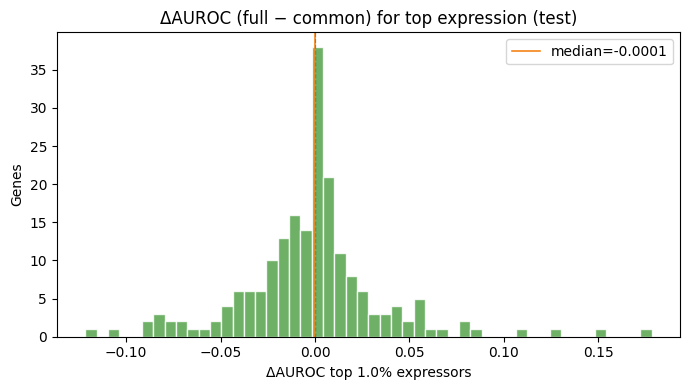

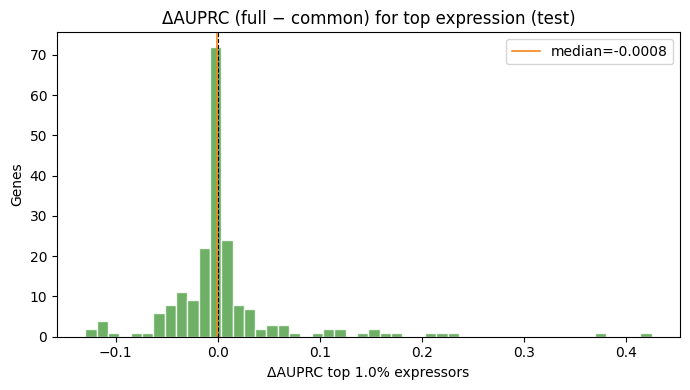

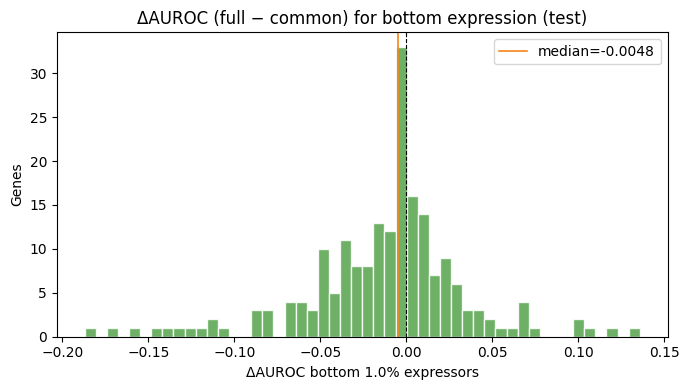

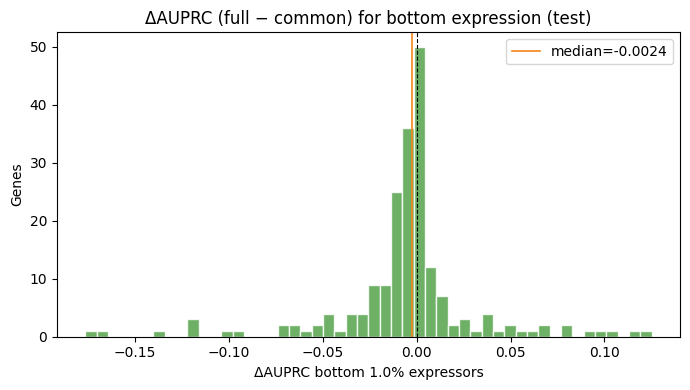

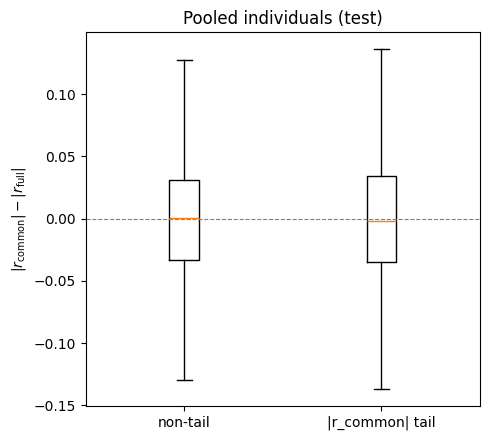

In [7]:
etp.plot_summary_figures(
    prep,
    expr_quantile=manifest.get("expr_tail_quantile"),
    show=True,
)

## ROC / PR for one gene

Uses saved `individual_gene_residuals.csv.gz` when present; otherwise recomputes one gene.

demo gene: chr1/ENSG00000158022


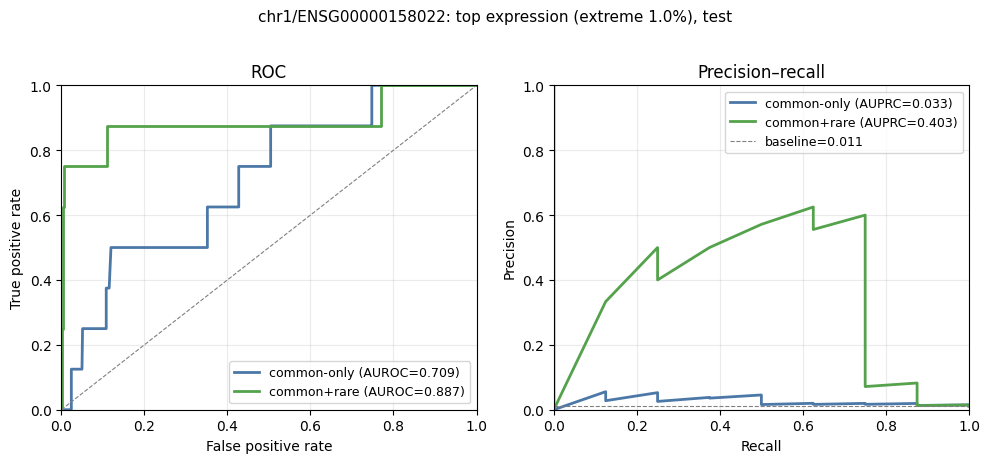

{'gene': 'chr1/ENSG00000158022',
 'split': 'test',
 'expr_extreme': 'top',
 'auroc_common': 0.708511396011396,
 'auroc_full': 0.8867521367521368,
 'auprc_common': 0.03318317988259861,
 'auprc_full': 0.40333584936706923,
 'delta_auroc': 0.1782407407407408,
 'delta_auprc': 0.3701526694844706}

In [8]:
demo_gene = etp.pick_gene_for_roc_pr(gene_df, split=SPLIT, expr_extreme="top")
print("demo gene:", demo_gene)

# Use saved individuals from prep (no pyro / recompute needed)
stats = etp.plot_gene_roc_pr(
    ind_df,
    gene=demo_gene,
    split=SPLIT,
    expr_extreme="top",
    expr_quantile=manifest.get("expr_tail_quantile", 0.01),
)
stats